# Full hand reconstruction (fixed)

This notebook loads a glove CSV, extracts left or right hand quaternions from a selected row, computes relative rotations for each finger, builds a simple forward-kinematics chain, and plots the reconstructed hand. The uploaded notebook used palm/finger quaternion columns such as `left_palm_prox_quat_w`, `left_index_prox_quat_w`, `left_index_mid_quat_w`, and `right_wrist_quat_w`, so this version normalizes around the available underscore-style column names in that file structure. [file:118]

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
def normalize_quaternion(q):
    q = np.asarray(q, dtype=float).reshape(4,)
    n = np.linalg.norm(q)
    if n == 0:
        raise ValueError('Zero quaternion cannot be normalized')
    return q / n


def quat_to_rotmat(q, order='wxyz'):
    q = normalize_quaternion(q)
    if order == 'wxyz':
        w, x, y, z = q
    elif order == 'xyzw':
        x, y, z, w = q
    else:
        raise ValueError("order must be 'wxyz' or 'xyzw'")

    return np.array([
        [1 - 2*(y*y + z*z), 2*(x*y - z*w),     2*(x*z + y*w)],
        [2*(x*y + z*w),     1 - 2*(x*x + z*z), 2*(y*z - x*w)],
        [2*(x*z - y*w),     2*(y*z + x*w),     1 - 2*(x*x + y*y)]
    ], dtype=float)


def T_translate(t):
    T = np.eye(4, dtype=float)
    T[:3, 3] = np.asarray(t, dtype=float).reshape(3,)
    return T


def T_rotate(R):
    T = np.eye(4, dtype=float)
    T[:3, :3] = np.asarray(R, dtype=float).reshape(3, 3)
    return T


def make_transform(R, t):
    T = np.eye(4, dtype=float)
    T[:3, :3] = R
    T[:3, 3] = np.asarray(t, dtype=float).reshape(3,)
    return T


def relative_rotation(R_parent, R_child):
    return R_parent.T @ R_child

In [8]:
CSV_PATH = '/home/jestin/ThesisRepo/ML/3D_Reconstruction/glove_data_flat_fist_one_2s_2_2026-04-25_14-32-51.csv'
HAND_SIDE = 'left'     # 'left' or 'right'
ROW_SELECT = 2         # choose the frame index you want
QUAT_ORDER = 'wxyz'    # CSV columns are loaded as w,x,y,z
AXIS_FIX = np.eye(3)   # replace with a fixed IMU-to-link alignment if needed

csv_path = Path(CSV_PATH)
if not csv_path.exists():
    raise FileNotFoundError(f'CSV not found: {csv_path.resolve()}')

df = pd.read_csv(csv_path)
print(f'Loaded: {csv_path}')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Selected row: {ROW_SELECT}')

Loaded: /home/jestin/ThesisRepo/ML/3D_Reconstruction/glove_data_flat_fist_one_2s_2_2026-04-25_14-32-51.csv
Shape: 64 rows x 295 columns
Selected row: 2


In [9]:
def qcols_underscore(prefix):
    return [f'{prefix}_quat_w', f'{prefix}_quat_x', f'{prefix}_quat_y', f'{prefix}_quat_z']


def extract_quaternion_from_row(row, prefixes, required=True):
    for prefix in prefixes:
        cols = qcols_underscore(prefix)
        if all(c in row.index for c in cols):
            return np.array([row[cols[0]], row[cols[1]], row[cols[2]], row[cols[3]]], dtype=float), prefix
    if required:
        raise KeyError(f'No quaternion columns found for prefixes: {prefixes}')
    return None, None


def load_hand_quaternions(df, row_idx, hand_side='left'):
    row = df.iloc[row_idx]
    side = hand_side.lower()
    if side not in {'left', 'right'}:
        raise ValueError("hand_side must be 'left' or 'right'")

    palm_q, palm_src = extract_quaternion_from_row(
        row,
        [f'{side}_wrist', f'{side}_palm_prox', f'{side}_palm_mid'],
        required=True
    )

    hand = {
        'Palm': palm_q,
        '_sources': {'Palm': palm_src}
    }

    for finger in ['thumb', 'index', 'middle', 'ring', 'pinky']:
        prox_q, prox_src = extract_quaternion_from_row(row, [f'{side}_{finger}_prox'], required=False)
        mid_q, mid_src = extract_quaternion_from_row(row, [f'{side}_{finger}_mid'], required=False)

        if prox_q is None and mid_q is None:
            continue
        if prox_q is None:
            prox_q = mid_q.copy()
            prox_src = f'{mid_src} (fallback for prox)'
        if mid_q is None:
            mid_q = prox_q.copy()
            mid_src = f'{prox_src} (fallback for mid)'

        hand[finger.capitalize()] = {
            'Proximal': prox_q,
            'Mid': mid_q
        }
        hand['_sources'][finger.capitalize()] = {
            'Proximal': prox_src,
            'Mid': mid_src
        }

    return hand

In [10]:
LeftHand = load_hand_quaternions(df, ROW_SELECT, HAND_SIDE)
LeftHand['_sources']

{'Palm': 'left_wrist',
 'Thumb': {'Proximal': 'left_thumb_prox', 'Mid': 'left_thumb_mid'},
 'Index': {'Proximal': 'left_index_prox', 'Mid': 'left_index_mid'},
 'Middle': {'Proximal': 'left_middle_prox', 'Mid': 'left_middle_mid'},
 'Ring': {'Proximal': 'left_ring_prox', 'Mid': 'left_ring_mid'},
 'Pinky': {'Proximal': 'left_pinky_prox', 'Mid': 'left_pinky_mid'}}

In [11]:
LeftHand_RotMats = {'Palm': quat_to_rotmat(LeftHand['Palm'], order=QUAT_ORDER) @ AXIS_FIX}

for finger in ['Thumb', 'Index', 'Middle', 'Ring', 'Pinky']:
    if finger not in LeftHand:
        continue

    R_prox_global = quat_to_rotmat(LeftHand[finger]['Proximal'], order=QUAT_ORDER) @ AXIS_FIX
    R_mid_global = quat_to_rotmat(LeftHand[finger]['Mid'], order=QUAT_ORDER) @ AXIS_FIX

    LeftHand_RotMats[finger] = {
        'Global': {
            'Proximal': R_prox_global,
            'Mid': R_mid_global
        },
        'Relative': {
            'Palm2Proximal': relative_rotation(LeftHand_RotMats['Palm'], R_prox_global),
            'Proximal2Mid': relative_rotation(R_prox_global, R_mid_global)
        }
    }

LeftHand_RotMats['Index']['Relative'] if 'Index' in LeftHand_RotMats else LeftHand_RotMats

{'Palm2Proximal': array([[ 0.98028511, -0.01596719,  0.19694201],
        [ 0.02211336,  0.99933337, -0.02904841],
        [-0.1963469 ,  0.03283078,  0.97998471]]),
 'Proximal2Mid': array([[ 0.99991954,  0.01021958, -0.00751539],
        [-0.00999604,  0.99952351,  0.02920323],
        [ 0.00781025, -0.02912575,  0.99954524]])}

In [12]:
LeftHand_Links = {
    'Palm': np.array([0.0, 0.0, 0.0]),
    'Thumb': {
        'Metacarpal': np.array([-25.0,   0.0,  0.0]),
        'Proximal':   np.array([  0.0, -40.0,  0.0]),
        'Mid':        np.array([  0.0, -30.0,  0.0]),
        'Distal':     np.array([  0.0, -20.0,  0.0])
    },
    'Index': {
        'Metacarpal': np.array([-25.0, -80.0,  0.0]),
        'Proximal':   np.array([  0.0, -40.0,  0.0]),
        'Mid':        np.array([  0.0, -30.0,  0.0]),
        'Distal':     np.array([  0.0, -20.0,  0.0])
    },
    'Middle': {
        'Metacarpal': np.array([  0.0, -80.0,  0.0]),
        'Proximal':   np.array([  0.0, -45.0,  0.0]),
        'Mid':        np.array([  0.0, -35.0,  0.0]),
        'Distal':     np.array([  0.0, -22.0,  0.0])
    },
    'Ring': {
        'Metacarpal': np.array([ 20.0, -78.0,  0.0]),
        'Proximal':   np.array([  0.0, -42.0,  0.0]),
        'Mid':        np.array([  0.0, -30.0,  0.0]),
        'Distal':     np.array([  0.0, -20.0,  0.0])
    },
    'Pinky': {
        'Metacarpal': np.array([ 40.0, -72.0,  0.0]),
        'Proximal':   np.array([  0.0, -35.0,  0.0]),
        'Mid':        np.array([  0.0, -24.0,  0.0]),
        'Distal':     np.array([  0.0, -18.0,  0.0])
    }
}

In [13]:
def build_hand_transforms(rotmats, links):
    transforms = {'Palm': np.eye(4, dtype=float)}

    for finger in ['Thumb', 'Index', 'Middle', 'Ring', 'Pinky']:
        if finger not in rotmats:
            continue

        T_palm_to_knuckle = T_translate(links[finger]['Metacarpal'])
        T_knuckle_to_prox = T_rotate(rotmats[finger]['Relative']['Palm2Proximal'])
        T_prox_link = T_translate(links[finger]['Proximal'])
        T_prox_to_mid = T_rotate(rotmats[finger]['Relative']['Proximal2Mid'])
        T_mid_link = T_translate(links[finger]['Mid'])
        T_dist_link = T_translate(links[finger]['Distal'])

        T_prox = transforms['Palm'] @ T_palm_to_knuckle @ T_knuckle_to_prox
        T_mid = T_prox @ T_prox_link @ T_prox_to_mid
        T_tip = T_mid @ T_mid_link @ T_dist_link

        transforms[finger] = {
            'Knuckle': transforms['Palm'] @ T_palm_to_knuckle,
            'Proximal': T_prox,
            'Mid': T_mid,
            'Tip': T_tip
        }

    return transforms

In [14]:
LeftHand_Transforms = build_hand_transforms(LeftHand_RotMats, LeftHand_Links)
LeftHand_Transforms['Index']['Tip'] if 'Index' in LeftHand_Transforms else LeftHand_Transforms

array([[ 9.81904006e-01, -1.16775648e-02,  1.89018935e-01,
        -2.37774341e+01],
       [ 1.18953304e-02,  9.99929248e-01, -1.76380485e-05,
        -1.69969797e+02],
       [-1.89005356e-01,  2.26576156e-03,  9.81973443e-01,
        -1.42651924e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

In [15]:
def plot_frame(ax, T, axis_len=10.0, label=None):
    origin = T[:3, 3]
    R = T[:3, :3]
    ex = R @ np.array([axis_len, 0.0, 0.0])
    ey = R @ np.array([0.0, axis_len, 0.0])
    ez = R @ np.array([0.0, 0.0, axis_len])

    ax.quiver(*origin, *ex, color='r')
    ax.quiver(*origin, *ey, color='g')
    ax.quiver(*origin, *ez, color='b')
    if label is not None:
        ax.text(origin[0], origin[1], origin[2], label, color='black', fontsize=9)


def extract_point(T):
    return T[:3, 3]

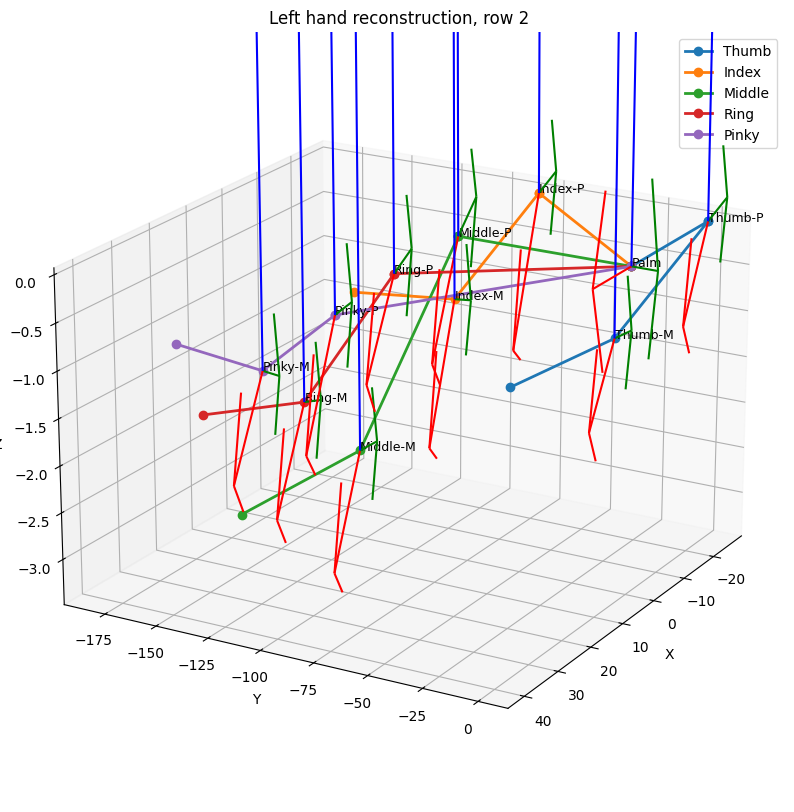

In [16]:
plt.rcParams['figure.figsize'] = (12, 10)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

plot_frame(ax, LeftHand_Transforms['Palm'], axis_len=12, label='Palm')

for finger in ['Thumb', 'Index', 'Middle', 'Ring', 'Pinky']:
    if finger not in LeftHand_Transforms:
        continue

    T_knuckle = LeftHand_Transforms[finger]['Knuckle']
    T_prox = LeftHand_Transforms[finger]['Proximal']
    T_mid = LeftHand_Transforms[finger]['Mid']
    T_tip = LeftHand_Transforms[finger]['Tip']

    p0 = extract_point(LeftHand_Transforms['Palm'])
    p1 = extract_point(T_knuckle)
    p2 = extract_point(T_prox)
    p3 = extract_point(T_mid)
    p4 = extract_point(T_tip)

    pts = np.vstack([p0, p1, p2, p3, p4])
    ax.plot(pts[:, 0], pts[:, 1], pts[:, 2], marker='o', linewidth=2, label=finger)

    plot_frame(ax, T_prox, axis_len=8, label=f'{finger}-P')
    plot_frame(ax, T_mid, axis_len=8, label=f'{finger}-M')

ax.set_title(f'{HAND_SIDE.capitalize()} hand reconstruction, row {ROW_SELECT}')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_box_aspect([1, 1, 0.7])
ax.legend()
ax.view_init(elev=20, azim=30)
plt.show()

## Notes

This fixed notebook corrects several issues in the uploaded version: it uses the available underscore-style CSV column names, keeps quaternion ordering consistent, computes relative rotations with transpose instead of general matrix inversion for rotations, and builds a complete global transform chain before plotting. The uploaded notebook mixed absolute and relative rotations and plotted only partial transform translations, which is why the reconstruction logic was incomplete. [file:118][file:41]